In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded ✅')

Libraries loaded ✅


In [4]:
df_raw = pd.read_excel('netflix_titles.xlsx', dtype={'show_id': str})

print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head()

Shape: (8807, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25 00:00:00,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirst..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, ...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets o..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari,...",NaN,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adve...","To protect his family from a powerful drug lord, skilled..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the inc..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaa...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies",In a city of coaching centers known to train India’s fin...


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(2)

null_report = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
null_report[null_report.null_count > 0].sort_values('null_%', ascending=False)

,null_count,null_%
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


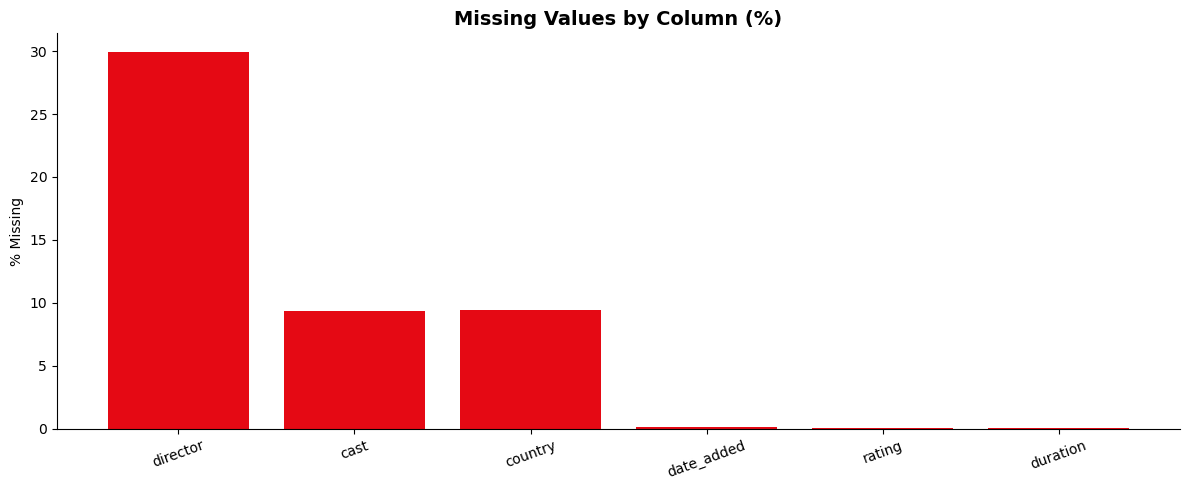

In [7]:
cols_with_nulls = null_report[null_report.null_count > 0]
plt.bar(cols_with_nulls.index, cols_with_nulls['null_%'], color='#E50914')
plt.title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
plt.ylabel('% Missing')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

In [ ]:
# lets clean the data now

In [8]:
df = df_raw.copy()

In [9]:
before = len(df)
df.drop_duplicates(subset='show_id', keep='first', inplace=True)
print(f'Duplicates removed: {before - len(df)}')

Duplicates removed: 0


In [10]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

In [11]:
rating_mode = df['rating'].mode()[0]
df['rating'].fillna(rating_mode, inplace=True)

In [12]:
df['duration'] = df.groupby('type')['duration'].transform(lambda x: x.fillna(x.mode()[0]))


In [13]:
df['date_added'].fillna('January 1, 2000', inplace=True)


In [14]:
print('Remaining nulls after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining nulls after cleaning:
Series([], dtype: int64)


In [ ]:
# lets fix dtatypes

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [16]:
df['release_year'] = df['release_year'].astype(int)


In [18]:
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())
print('Dtypes after fix:')
print(df.dtypes)

Dtypes after fix:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int32
rating                  object
duration                object
listed_in               object
description             object
dtype: object


In [19]:
df['duration_int']  = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'[\d]+ (.+)')

print(df[['type','duration','duration_int','duration_unit']].drop_duplicates('duration_unit'))

      type   duration  duration_int duration_unit
0    Movie     90 min          90.0           min
1  TV Show  2 Seasons           2.0       Seasons
2  TV Show   1 Season           1.0        Season


In [20]:
bad_ratings = df[~df['rating'].isin(['G','PG','PG-13','R','NC-17',
                                     'TV-Y','TV-Y7','TV-Y7-FV','TV-G',
                                     'TV-PG','TV-14','TV-MA','NR','UR'])]
print('Bad rating rows:', len(bad_ratings))

Bad rating rows: 3


In [21]:
mask = df['rating'].str.contains(r'\d+ min', na=False)
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating']   = 'NR'

print('Unique ratings after fix:', df['rating'].unique())

Unique ratings after fix: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']


In [22]:
print('Total nulls remaining:', df.isnull().sum().sum())
print('Shape after cleaning:', df.shape)

Total nulls remaining: 24
Shape after cleaning: (8807, 14)


In [ ]:
# lets transform tyhe dataset

In [23]:
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name']  = df['date_added'].dt.strftime('%B')
df['quarter_added'] = df['date_added'].dt.quarter

df[['date_added','year_added','month_added','month_name','quarter_added']].head()

,date_added,year_added,month_added,month_name,quarter_added
0,2021-09-25,2021,9,September,3
1,2021-09-24,2021,9,September,3
2,2021-09-24,2021,9,September,3
3,2021-09-24,2021,9,September,3
4,2021-09-24,2021,9,September,3


In [24]:
df['content_age_at_addition'] = df['year_added'] - df['release_year']

In [25]:
df['content_age_at_addition'] = df['content_age_at_addition'].clip(lower=0)
df['content_age_at_addition'].describe()

count    8807.000000
mean        4.685023
std         8.782236
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age_at_addition, dtype: float64

In [26]:
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df['primary_country'].value_counts().head(10)

primary_country
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64

In [27]:
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
df['primary_genre'].value_counts().head(10)

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

In [29]:
rating_map = {
    'G':'Kids', 'TV-Y':'Kids', 'TV-Y7':'Kids', 'TV-Y7-FV':'Kids', 'TV-G':'Kids',
    'PG':'Family', 'TV-PG':'Family',
    'PG-13':'Teens', 'TV-14':'Teens',
    'R':'Adults', 'TV-MA':'Adults', 'NC-17':'Adults',
    'NR':'Not Rated', 'UR':'Not Rated'
}
df['audience'] = df['rating'].map(rating_map).fillna('Not Rated')
df['audience'].value_counts()

audience
Adults       4013
Teens        2650
Family       1150
Kids          908
Not Rated      86
Name: count, dtype: int64

In [30]:
df_genres = df[['show_id','title','type','listed_in']].copy()
df_genres['genre'] = df_genres['listed_in'].str.split(',')
df_genres = df_genres.explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()
df_genres.drop(columns='listed_in', inplace=True)
print('Exploded genres shape:', df_genres.shape)
df_genres.head()

Exploded genres shape: (19323, 4)


,show_id,title,type,genre
0,s1,Dick Johnson Is Dead,Movie,Documentaries
1,s2,Blood & Water,TV Show,International TV Shows
1,s2,Blood & Water,TV Show,TV Dramas
1,s2,Blood & Water,TV Show,TV Mysteries
2,s3,Ganglands,TV Show,Crime TV Shows


In [31]:
df_countries = df[['show_id','title','type','country']].copy()
df_countries['country_single'] = df_countries['country'].str.split(',')
df_countries = df_countries.explode('country_single')
df_countries['country_single'] = df_countries['country_single'].str.strip()
df_countries = df_countries[df_countries['country_single'] != 'Unknown']
df_countries.drop(columns='country', inplace=True)
print('Exploded countries shape:', df_countries.shape)
df_countries.head()

Exploded countries shape: (10019, 4)


,show_id,title,type,country_single
0,s1,Dick Johnson Is Dead,Movie,United States
1,s2,Blood & Water,TV Show,South Africa
4,s5,Kota Factory,TV Show,India
7,s8,Sankofa,Movie,United States
7,s8,Sankofa,Movie,Ghana


In [ ]:
# lets analyse the dataset now

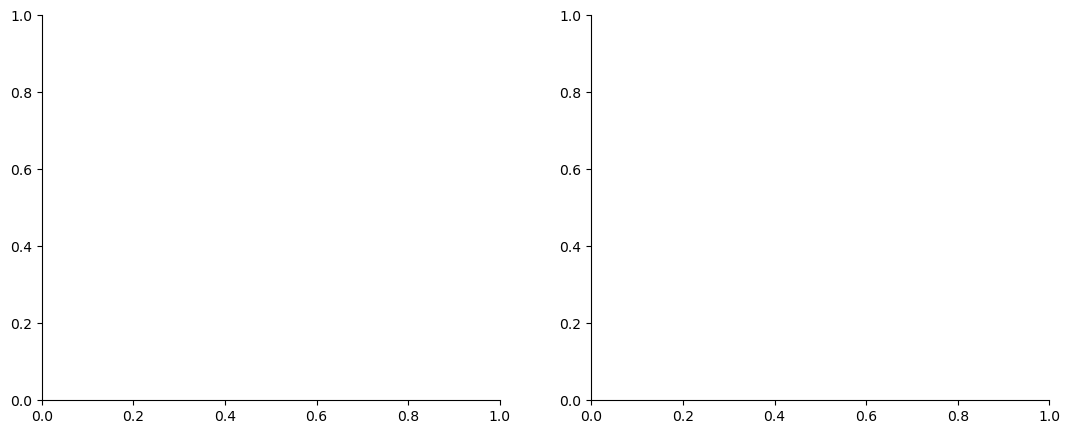

In [32]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

In [33]:
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#E50914','#221F1F'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Movies vs TV Shows', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Movies vs TV Shows')

In [36]:
axes[1].bar(type_counts.index, type_counts.values, color=['#E50914','#B81D24'], width=0.4)
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[1].set_title('Content Count by Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('type_split.png', dpi=150)
plt.show()

<Figure size 1200x500 with 0 Axes>

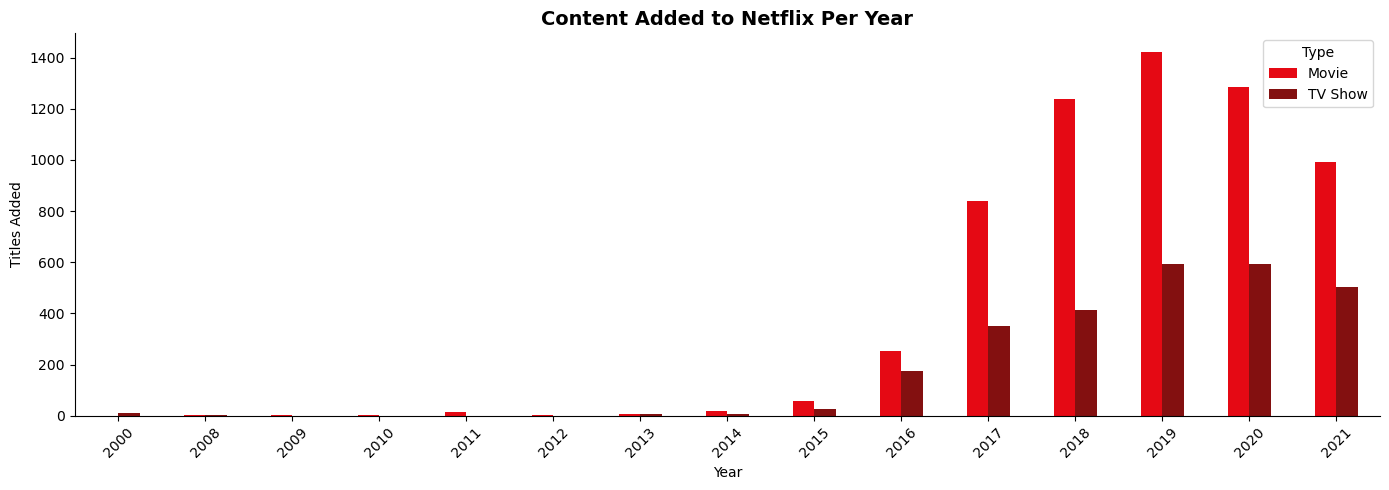

In [37]:
yearly = df.groupby(['year_added','type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index.notna()].astype(int)

yearly.plot(kind='bar', color=['#E50914','#831010'], figsize=(14,5))
plt.title('Content Added to Netflix Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('content_per_year.png', dpi=150)
plt.show()

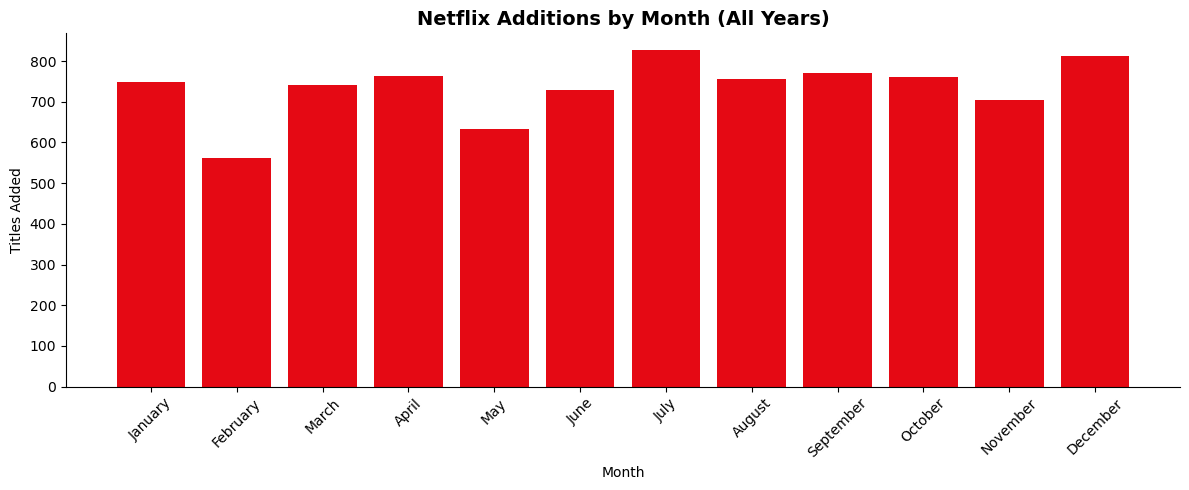

In [38]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df['month_name'].value_counts().reindex(month_order)

plt.bar(monthly.index, monthly.values, color='#E50914')
plt.title('Netflix Additions by Month (All Years)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_additions.png', dpi=150)
plt.show()

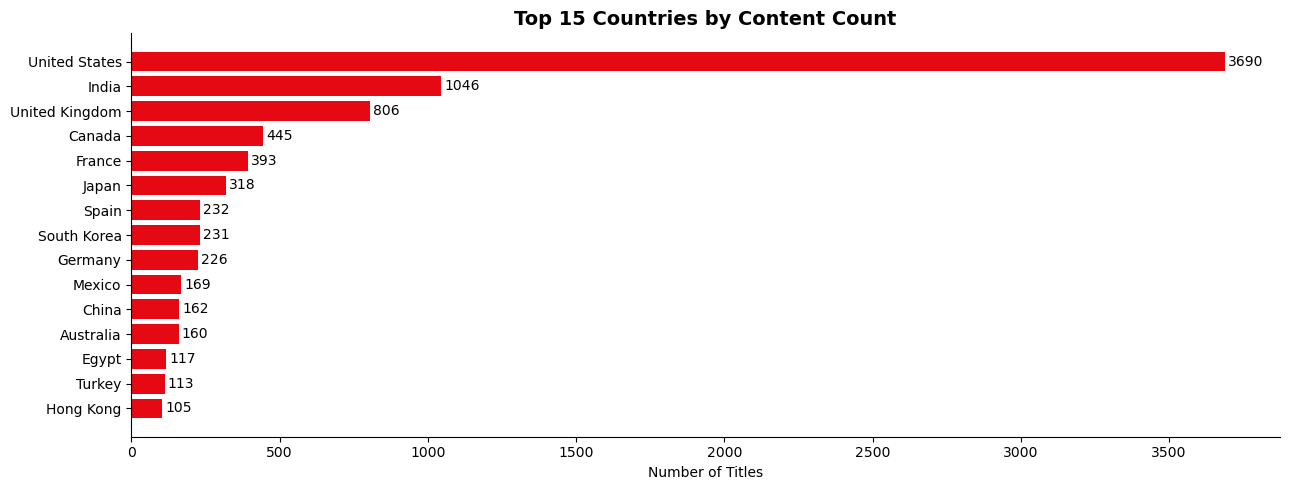

In [39]:
top_countries = df_countries['country_single'].value_counts().head(15)

plt.figure(figsize=(13,5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#E50914')
plt.title('Top 15 Countries by Content Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
for i, v in enumerate(top_countries.values[::-1]):
    plt.text(v + 10, i, str(v), va='center')
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150)
plt.show()

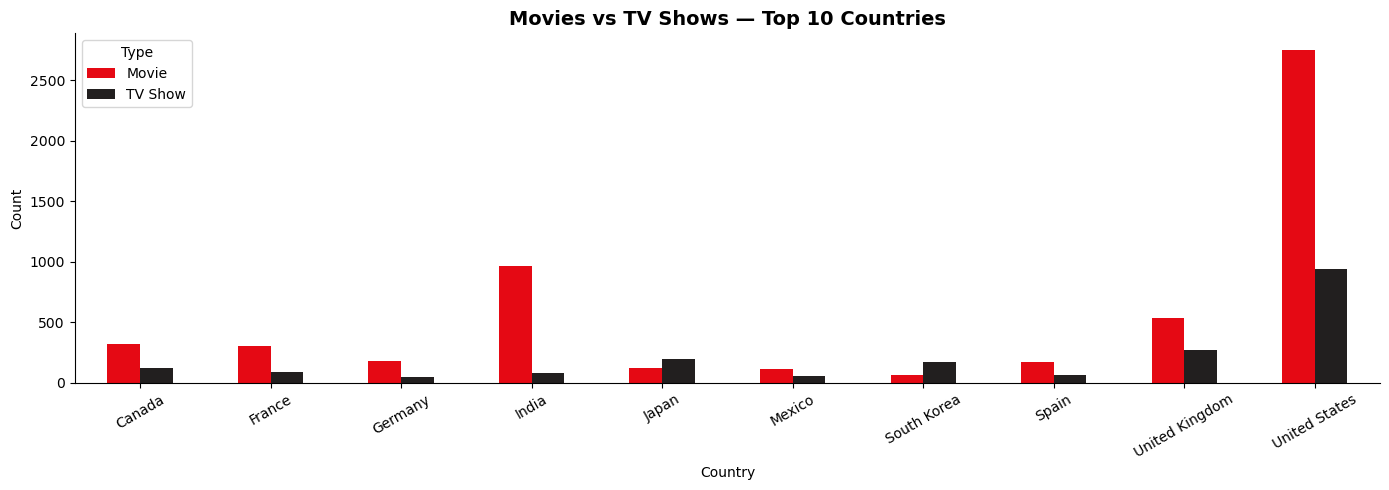

In [40]:
top10 = df_countries['country_single'].value_counts().head(10).index
ct = df_countries[df_countries['country_single'].isin(top10)]\
       .groupby(['country_single','type']).size().unstack(fill_value=0)

ct.plot(kind='bar', color=['#E50914','#221F1F'], figsize=(14,5))
plt.title('Movies vs TV Shows — Top 10 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('country_type.png', dpi=150)
plt.show()

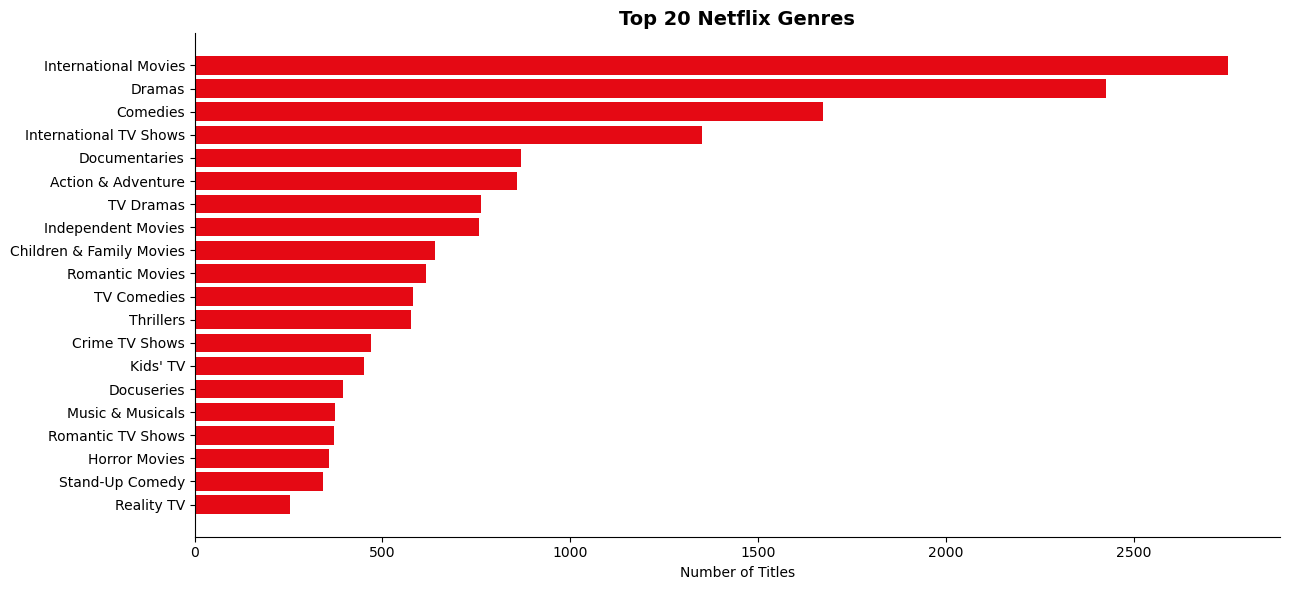

In [41]:
top_genres = df_genres['genre'].value_counts().head(20)

plt.figure(figsize=(13,6))
plt.barh(top_genres.index[::-1], top_genres.values[::-1], color='#E50914')
plt.title('Top 20 Netflix Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('top_genres.png', dpi=150)
plt.show()

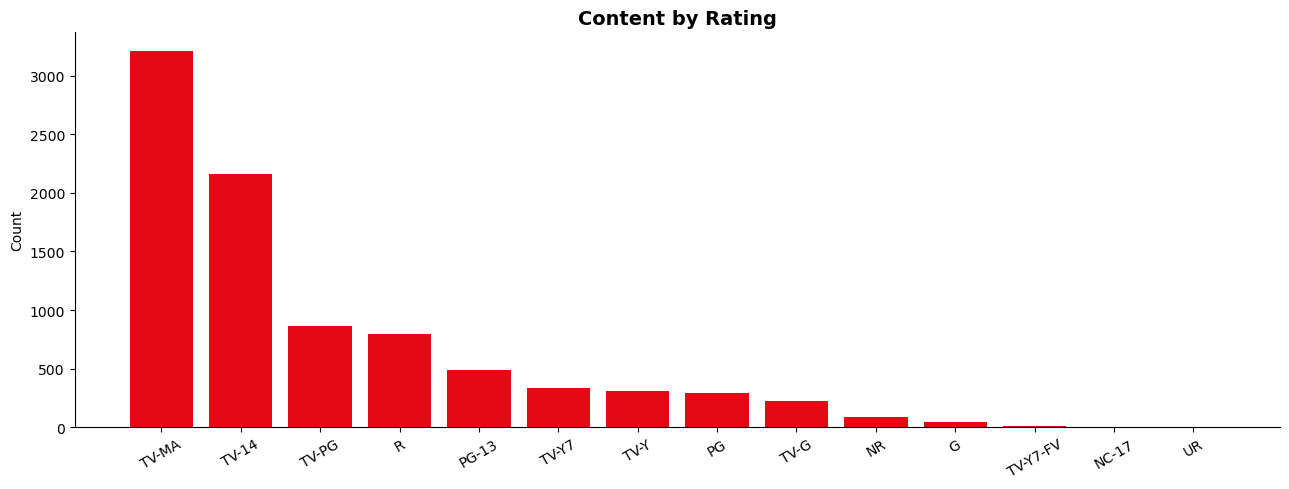

In [42]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(13,5))
plt.bar(rating_counts.index, rating_counts.values, color='#E50914')
plt.title('Content by Rating', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('rating_dist.png', dpi=150)
plt.show()

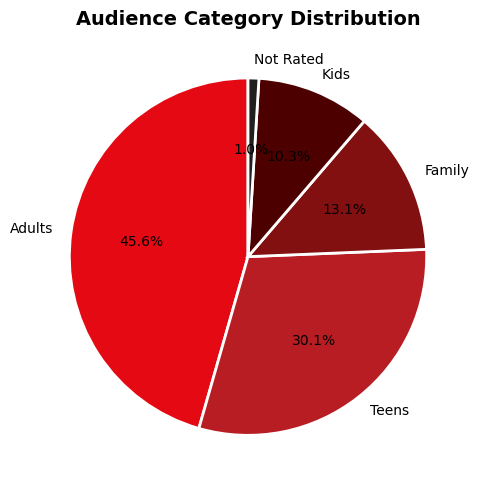

In [43]:
audience_counts = df['audience'].value_counts()

colors = ['#E50914','#B81D24','#831010','#4D0000','#221F1F']
plt.pie(audience_counts, labels=audience_counts.index, autopct='%1.1f%%',
        colors=colors[:len(audience_counts)], startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('Audience Category Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('audience_split.png', dpi=150)
plt.show()

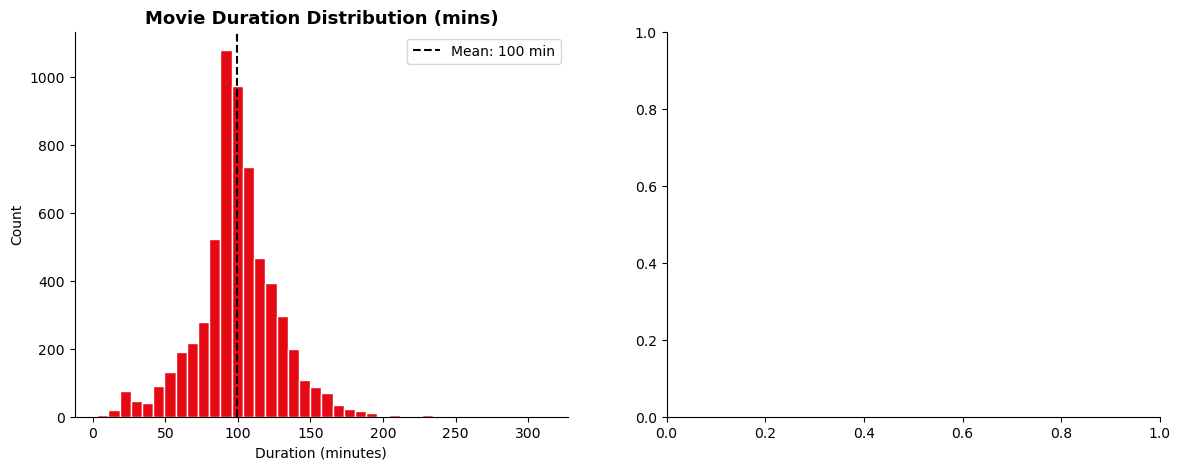

In [44]:
movies = df[df['type'] == 'Movie']['duration_int'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(movies, bins=40, color='#E50914', edgecolor='white')
axes[0].set_title('Movie Duration Distribution (mins)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].axvline(movies.mean(), color='black', linestyle='--', label=f'Mean: {movies.mean():.0f} min')
axes[0].legend()


In [45]:
shows = df[df['type'] == 'TV Show']['duration_int'].dropna()
season_counts = shows.value_counts().sort_index()
axes[1].bar(season_counts.index, season_counts.values, color='#B81D24')
axes[1].set_title('TV Show — Number of Seasons', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Seasons')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('duration_dist.png', dpi=150)
plt.show()

print(f'Movie stats — Mean: {movies.mean():.0f} min | Median: {movies.median():.0f} min | Std: {movies.std():.0f} min')

<Figure size 1200x500 with 0 Axes>

Movie stats — Mean: 100 min | Median: 98 min | Std: 28 min


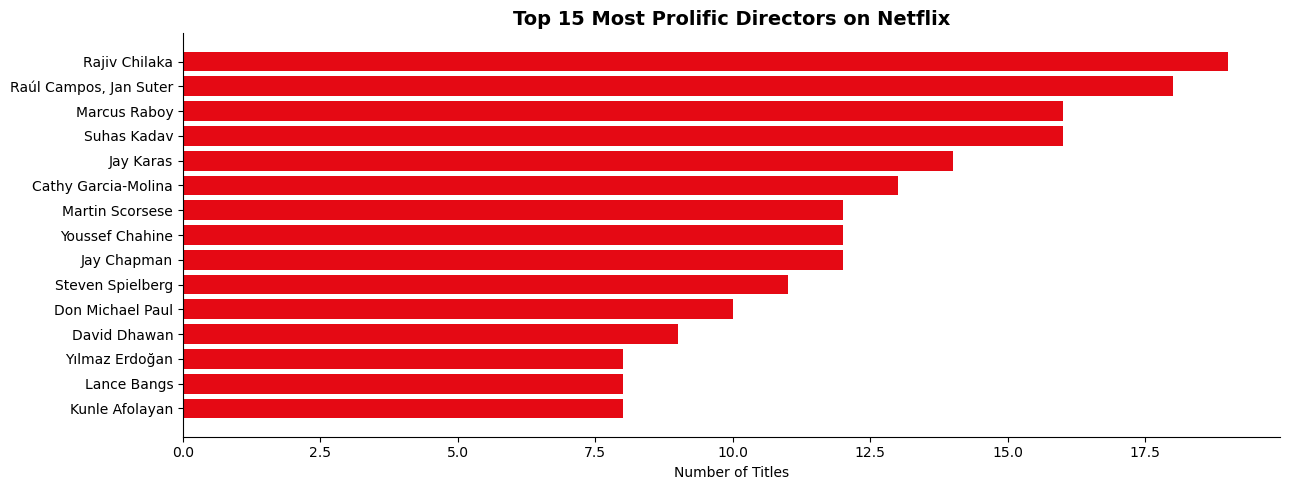

In [46]:
top_directors = (df[df['director'] != 'Unknown']['director']
                 .value_counts().head(15))

plt.figure(figsize=(13,5))
plt.barh(top_directors.index[::-1], top_directors.values[::-1], color='#E50914')
plt.title('Top 15 Most Prolific Directors on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('top_directors.png', dpi=150)
plt.show()

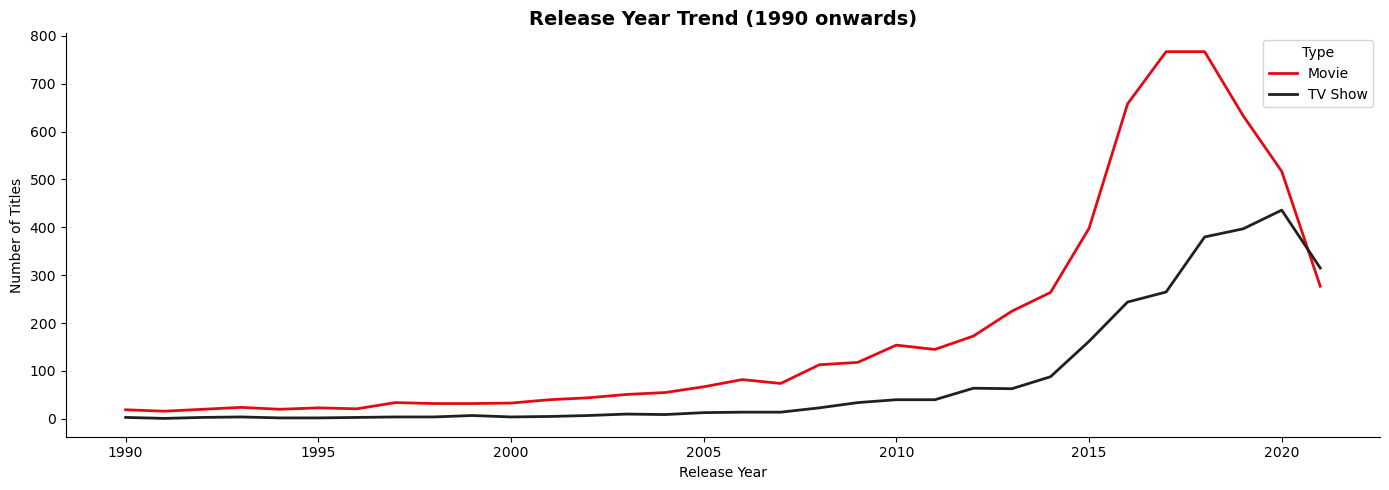

In [47]:
release_trend = df.groupby(['release_year','type']).size().unstack(fill_value=0)
release_trend = release_trend[release_trend.index >= 1990]

release_trend.plot(kind='line', color=['#E50914','#221F1F'], linewidth=2, figsize=(14,5))
plt.title('Release Year Trend (1990 onwards)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('release_year_trend.png', dpi=150)
plt.show()

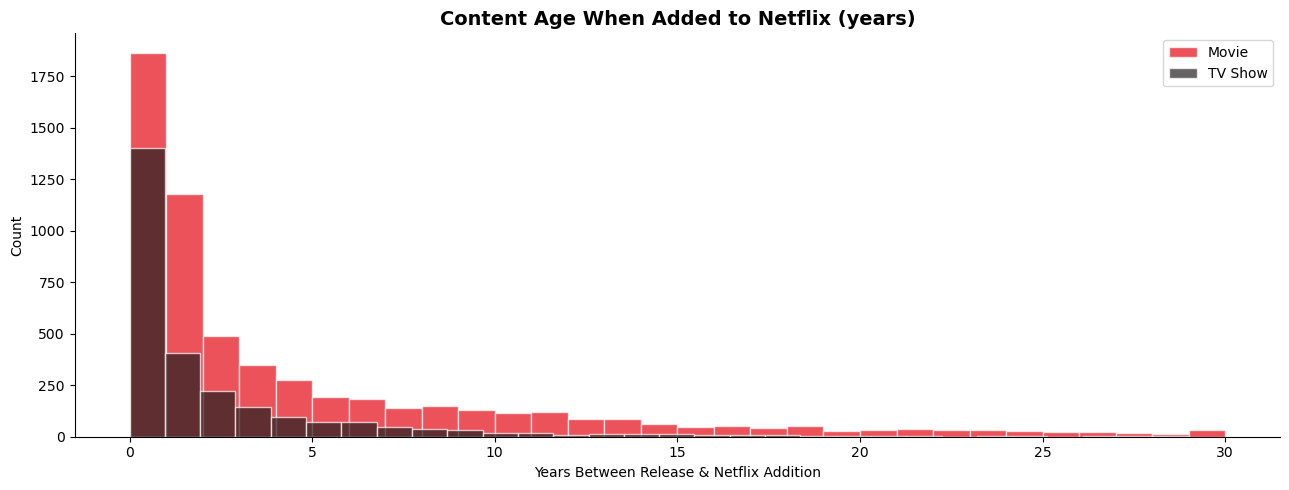

In [48]:
age_data = df[df['content_age_at_addition'] <= 30]  # exclude extreme outliers

plt.figure(figsize=(13,5))
for t, color in zip(['Movie','TV Show'],['#E50914','#221F1F']):
    subset = age_data[age_data['type'] == t]['content_age_at_addition']
    plt.hist(subset, bins=30, alpha=0.7, label=t, color=color, edgecolor='white')
plt.title('Content Age When Added to Netflix (years)', fontsize=14, fontweight='bold')
plt.xlabel('Years Between Release & Netflix Addition')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('content_age.png', dpi=150)
plt.show()

In [49]:
movie_durations = df[df['type']=='Movie']['duration_int'].dropna().values

stats = {
    'count'     : int(np.size(movie_durations)),
    'mean'      : np.mean(movie_durations),
    'median'    : np.median(movie_durations),
    'std'       : np.std(movie_durations),
    'variance'  : np.var(movie_durations),
    'min'       : np.min(movie_durations),
    'max'       : np.max(movie_durations),
    'q25'       : np.percentile(movie_durations, 25),
    'q75'       : np.percentile(movie_durations, 75),
    'iqr'       : np.percentile(movie_durations, 75) - np.percentile(movie_durations, 25)
}

print('=== Movie Duration Statistics (NumPy) ===')
for k, v in stats.items():
    print(f'  {k:<12}: {v:.2f}')

=== Movie Duration Statistics (NumPy) ===
  count       : 6131.00
  mean        : 99.57
  median      : 98.00
  std         : 28.28
  variance    : 799.88
  min         : 3.00
  max         : 312.00
  q25         : 87.00
  q75         : 114.00
  iqr         : 27.00


In [50]:
corr_data = df[['release_year','content_age_at_addition','duration_int']].dropna()
corr_matrix = np.corrcoef(corr_data.values.T)

print('Correlation Matrix (release_year, content_age, duration):')
print(np.round(corr_matrix, 3))

Correlation Matrix (release_year, content_age, duration):
[[ 1.    -0.983 -0.249]
 [-0.983  1.     0.256]
 [-0.249  0.256  1.   ]]


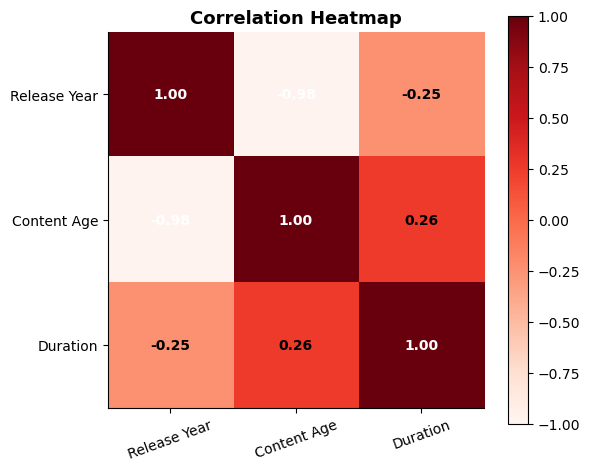

In [51]:
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr_matrix, cmap='Reds', vmin=-1, vmax=1)
plt.colorbar(im)
labels = ['Release Year', 'Content Age', 'Duration']
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(labels, rotation=20)
ax.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black', fontweight='bold')
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
# lets load the dataset to powerbi

In [52]:
df_export = df.drop(columns=['description'])  # optional: remove for smaller file
df_export.to_csv('netflix_clean.csv', index=False)
print('✅ netflix_clean.csv exported —', df_export.shape)

✅ netflix_clean.csv exported — (8807, 21)


In [53]:
df_genres.to_csv('netflix_genres.csv', index=False)
print('✅ netflix_genres.csv exported —', df_genres.shape)

✅ netflix_genres.csv exported — (19323, 4)


In [54]:
df_countries.to_csv('netflix_countries.csv', index=False)
print('✅ netflix_countries.csv exported —', df_countries.shape)

✅ netflix_countries.csv exported — (10019, 4)


In [55]:
yearly_summary = df.groupby(['year_added','type']).size().reset_index(name='count')
yearly_summary.to_csv('summary_yearly.csv', index=False)

In [56]:
country_summary = df_countries.groupby(['country_single','type']).size().reset_index(name='count')
country_summary.to_csv('summary_countries.csv', index=False)

In [57]:
genre_summary = df_genres.groupby(['genre','type']).size().reset_index(name='count')
genre_summary.to_csv('summary_genres.csv', index=False)

In [58]:
rating_summary = df.groupby(['rating','audience','type']).size().reset_index(name='count')
rating_summary.to_csv('summary_ratings.csv', index=False)

print('✅ All summary CSVs exported')

✅ All summary CSVs exported


In [59]:
print('=== FINAL CLEAN DATASET SUMMARY ===')
print(f'Total titles:     {len(df):,}')
print(f'Movies:           {(df.type=="Movie").sum():,}')
print(f'TV Shows:         {(df.type=="TV Show").sum():,}')
print(f'Countries:        {df["primary_country"].nunique():,}')
print(f'Unique genres:    {df_genres["genre"].nunique():,}')
print(f'Year range:       {df.release_year.min()} – {df.release_year.max()}')
print(f'Null count:       {df.isnull().sum().sum()}')
print(f'\nFiles ready for Power BI:')
import os
for f in ['netflix_clean.csv','netflix_genres.csv','netflix_countries.csv',
          'summary_yearly.csv','summary_countries.csv','summary_genres.csv','summary_ratings.csv']:
    if os.path.exists(f):
        print(f'  ✅ {f} ({os.path.getsize(f)/1024:.0f} KB)')

=== FINAL CLEAN DATASET SUMMARY ===
Total titles:     8,807
Movies:           6,131
TV Shows:         2,676
Countries:        87
Unique genres:    42
Year range:       1925 – 2021
Null count:       24

Files ready for Power BI:
  ✅ netflix_clean.csv (2556 KB)
  ✅ netflix_genres.csv (878 KB)
  ✅ netflix_countries.csv (411 KB)
  ✅ summary_yearly.csv (0 KB)
  ✅ summary_countries.csv (3 KB)
  ✅ summary_genres.csv (1 KB)
  ✅ summary_ratings.csv (1 KB)
